In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [14]:
df_original = pd.read_stata("Mexico-2023-full-data.dta")

cols = {
    "d2": "sales",
    "l1": "employees",     
    "b5": "start_year",
    "l10": "training",
    "k82": "financing",
    "d3c": "export_share"
}

df = df_original[list(cols.keys())].copy()
df.rename(columns=cols, inplace=True)

In [15]:
# Convertir columnas numéricas principales
for col in ["sales", "employees", "start_year", "export_share"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Mapear Yes/No (si aplica) y convertir a numérico
yes_no_map = {"Yes": 1, "No": 0, "YES": 1, "NO": 0}
for col in ["training", "financing"]:
    df[col] = df[col].replace(yes_no_map)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Exportador binario
df["exporter"] = (df["export_share"] > 0).astype(int)

# Edad empresa
SURVEY_YEAR = 2023
df["age"] = SURVEY_YEAR - df["start_year"]

# Productividad laboral
df["labor_prod"] = df["sales"] / df["employees"]

# Log ventas (para reducir outliers)
df["log_sales"] = np.log(df["sales"])

# Columnas mínimas para que el modelo tenga sentido
keep_cols = ["sales", "employees", "start_year", "training", "financing", "export_share",
             "exporter", "age", "labor_prod", "log_sales"]

df_final = df[keep_cols].dropna().copy()

df_final = df_final[
    (df_final["sales"] > 0) &
    (df_final["employees"] > 0) &
    (df_final["age"] >= 0) &
    (df_final["labor_prod"] > 0)
].copy()

print("Dataset limpio:", df_final.shape)
df_final.head()

Dataset limpio: (267, 10)


C:\Users\angel\AppData\Local\Temp\ipykernel_21868\2154121866.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(yes_no_map)
C:\Users\angel\AppData\Local\Temp\ipykernel_21868\2154121866.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace(yes_no_map)


,sales,employees,start_year,training,financing,export_share,exporter,age,labor_prod,log_sales
16,3600000,5,1985.0,0,0.0,0,0,38.0,720000.0,15.096444
22,6000000,6,2000.0,0,0.0,0,0,23.0,1000000.0,15.607270
28,6980000,8,2008.0,1,0.0,0,0,15.0,872500.0,15.758559
39,6000000,15,2011.0,0,0.0,0,0,12.0,400000.0,15.607270
46,11300000,10,2003.0,0,0.0,0,0,20.0,1130000.0,16.240313


In [16]:
mean_sales = df_final["sales"].mean()

df_final["successful"] = (df_final["sales"] > mean_sales).astype(int)

print("Promedio de ventas:", mean_sales)
print(df_final["successful"].value_counts())

Promedio de ventas: 49824207.074906364
successful
0    222
1     45
Name: count, dtype: int64


In [17]:
X = df_final[["employees", "training", "exporter", "financing", "age"]]
y = df_final["successful"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9814814814814815


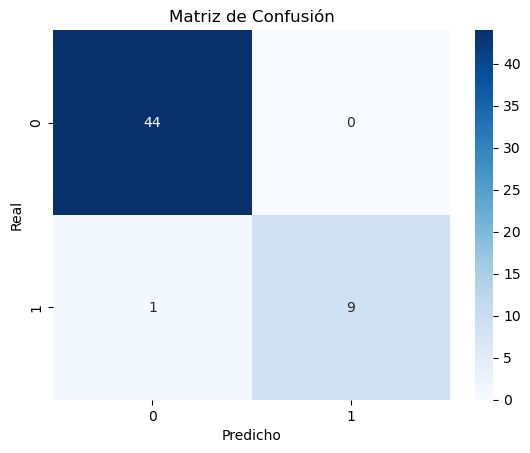

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

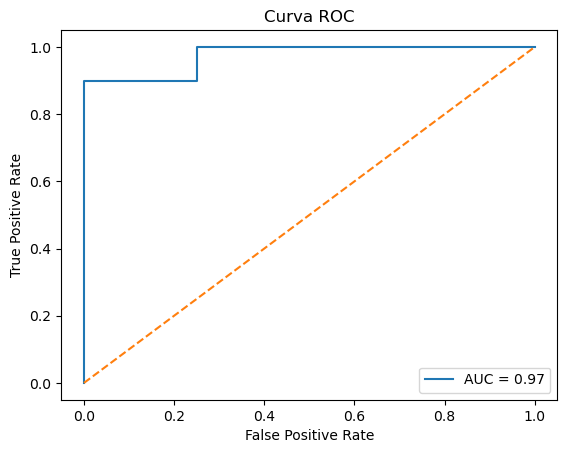

AUC: 0.975


In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

print("AUC:", auc)

## Conclusion
Los resultados muestran una precisión cercana al 98%, lo que indica que el modelo clasifica correctamente la gran mayoría de las empresas. La matriz de confusión confirma que el modelo comete muy pocos errores, identificando correctamente tanto empresas exitosas como no exitosas.

La curva ROC presenta un área bajo la curva (AUC) de aproximadamente 0.975, lo que indica una capacidad discriminatoria excelente. Esto sugiere que las variables seleccionadas permiten distinguir eficazmente entre empresas exitosas y no exitosas.

En conclusión, sí es posible clasificar el éxito empresarial utilizando características observables, y el modelo logístico demuestra un alto poder predictivo en este caso.